Week 5 Day 2

### AutoGen AgentChat - Going deeper..

1. Multi-modal conversation
2. Structured Outputs
3. Using LangChain tools
4. Teams

...and a special surprise extra piece

In [2]:
from io import BytesIO
import requests
from autogen_agentchat.messages import TextMessage, MultiModalMessage
from autogen_core import Image as AGImage
from PIL import Image
from dotenv import load_dotenv
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.agents import AssistantAgent
from autogen_core import CancellationToken
from IPython.display import display, Markdown
from pydantic import BaseModel, Field
from typing import Literal

load_dotenv(override=True)


True

### A multi-modal conversation


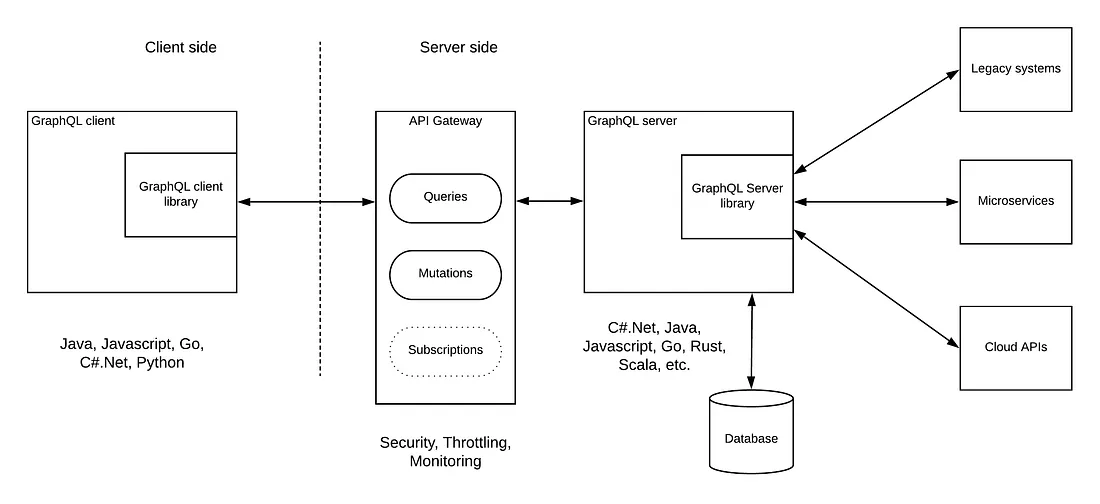

In [13]:
url = "https://edwarddonner.com/wp-content/uploads/2024/10/from-software-engineer-to-AI-DS.jpeg"
# url = "https://www.google.com/imgres?imgurl=https://www.tutorialspoint.com/graphql/images/graphql_server_integrating_existing_systems.jpg&tbnid=fVVHGMBl8CELCM&vet=1&imgrefurl=https://www.tutorialspoint.com/graphql/graphql_architecture.htm&docid=cfAO_l2fDeUudM&w=600&h=293&source=sh/x/im/m1/1&kgs=7918c6810a2d289e"
# pil_image = Image.open(BytesIO(requests.get(url).content))
image_path = "GraphQL.webp"
pil_image = Image.open(image_path)

img = AGImage(pil_image)

img

In [14]:
multi_modal_message = MultiModalMessage(content=["Describe the content of this image in detail", img], source="User")

In [15]:
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")

describer = AssistantAgent(
    name="description_agent",
    model_client=model_client,
    system_message="You are good at describing images",
)

response = await describer.on_messages([multi_modal_message], cancellation_token=CancellationToken())
reply = response.chat_message.content
display(Markdown(reply))

The image illustrates the architecture of a GraphQL API setup, comprising both client-side and server-side components.

### Client Side:
- **GraphQL Client**: Positioned on the left, it includes a representation of the GraphQL client library. The client can be implemented in various programming languages such as Java, JavaScript, Go, C#.Net, and Python.
- **Interaction**: A bidirectional arrow indicates communication between the GraphQL client and the server side, allowing the client to send requests and receive responses.

### Server Side:
- **API Gateway**: Central to the server side, the API gateway handles incoming requests and routes them appropriately. It includes:
  - **Queries**: For retrieving data.
  - **Mutations**: For modifying data.
  - **Subscriptions**: For real-time updates.
  
- **Security, Throttling, Monitoring**: These mechanisms are noted, indicating that the API gateway handles additional responsibilities related to securing and managing API traffic.

- **GraphQL Server**: Connected to the API gateway, it hosts the GraphQL server library. This server processes client requests and connects to various data sources.
  - **Supported Languages**: Similar to the client side, it supports several programming languages like C#.Net, Java, JavaScript, Go, Rust, Scala, etc.

### Data Sources:
- The GraphQL server interacts with a **Database** for data storage.
- Additionally, it connects with other systems:
  - **Legacy Systems**
  - **Microservices**
  - **Cloud APIs**

### Overall Structure:
The diagram conveys how a GraphQL architecture effectively facilitates client-server interactions while integrating with multiple data sources and ensuring security and performance management.

### Structured Outputs!

Autogen AgentChat makes it easy.

In [16]:

class ImageDescription(BaseModel):
    scene: str = Field(description="Briefly, the overall scene of the image")
    message: str = Field(description="The point that the image is trying to convey")
    style: str = Field(description="The artistic style of the image")
    orientation: Literal["portrait", "landscape", "square"] = Field(description="The orientation of the image")


In [17]:
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")

describer = AssistantAgent(
    name="description_agent",
    model_client=model_client,
    system_message="You are good at describing images in detail",
    output_content_type=ImageDescription,
)

response = await describer.on_messages([multi_modal_message], cancellation_token=CancellationToken())
reply = response.chat_message.content
reply

ImageDescription(scene='The image illustrates a system architecture diagram for a GraphQL setup, detailing connections between clients, an API gateway, and a server with various data sources.', message='This diagram conveys the flow of data and requests between client applications utilizing GraphQL libraries and a server that handles queries, mutations, and subscriptions. It also showcases how the server interacts with various data sources, including databases, legacy systems, microservices, and cloud APIs.', style='The diagram is presented in a simplified, technical schematic style, using boxes and arrows to represent components and their interactions clearly.', orientation='landscape')

In [18]:
import textwrap
print(f"Scene:\n{textwrap.fill(reply.scene)}\n\n")
print(f"Message:\n{textwrap.fill(reply.message)}\n\n")
print(f"Style:\n{textwrap.fill(reply.style)}\n\n")
print(f"Orientation:\n{textwrap.fill(reply.orientation)}\n\n")

Scene:
The image illustrates a system architecture diagram for a GraphQL
setup, detailing connections between clients, an API gateway, and a
server with various data sources.


Message:
This diagram conveys the flow of data and requests between client
applications utilizing GraphQL libraries and a server that handles
queries, mutations, and subscriptions. It also showcases how the
server interacts with various data sources, including databases,
legacy systems, microservices, and cloud APIs.


Style:
The diagram is presented in a simplified, technical schematic style,
using boxes and arrows to represent components and their interactions
clearly.


Orientation:
landscape




### Using LangChain tools from AutoGen

In [ ]:
# AutoGen's wrapper:

from autogen_ext.tools.langchain import LangChainToolAdapter

# LangChain tools:

from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.agent_toolkits import FileManagementToolkit
from langchain.agents import Tool


prompt = """Your task is to find a one-way non-stop flight from JFK to LHR in June 2025.
First search online for promising deals.
Next, write all the deals to a file called flights.md with full details.
Finally, select the one you think is best and reply with a short summary.
Reply with the selected flight only, and only after you have written the details to the file."""


serper = GoogleSerperAPIWrapper()
langchain_serper =Tool(name="internet_search", func=serper.run, description="useful for when you need to search the internet")
autogen_serper = LangChainToolAdapter(langchain_serper)
autogen_tools = [autogen_serper]

langchain_file_management_tools = FileManagementToolkit(root_dir="sandbox").get_tools()
for tool in langchain_file_management_tools:
    autogen_tools.append(LangChainToolAdapter(tool))

for tool in autogen_tools:
    print(tool.name, tool.description)

model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")
agent = AssistantAgent(name="searcher", model_client=model_client, tools=autogen_tools, reflect_on_tool_use=True)
message = TextMessage(content=prompt, source="user")
result = await agent.on_messages([message], cancellation_token=CancellationToken())
for message in result.inner_messages:
    print(message.content)
display(Markdown(result.chat_message.content))

In [ ]:
# Now we need to call the agent again to write the file

message = TextMessage(content="OK proceed", source="user")

result = await agent.on_messages([message], cancellation_token=CancellationToken())
for message in result.inner_messages:
    print(message.content)
display(Markdown(result.chat_message.content))

### Team interactions

In [2]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import  TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat

from autogen_ext.tools.langchain import LangChainToolAdapter
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import Tool

serper = GoogleSerperAPIWrapper()
langchain_serper =Tool(name="internet_search", func=serper.run, description="useful for when you need to search the internet")
autogen_serper = LangChainToolAdapter(langchain_serper)

model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")


prompt = """Find a one-way non-stop flight from JFK to LHR in June 2025."""


primary_agent = AssistantAgent(
    "primary",
    model_client=model_client,
    tools=[autogen_serper],
    system_message="You are a helpful AI research assistant who looks for promising deals on flights. Incorporate any feedback you receive.",
)

evaluation_agent = AssistantAgent(
    "evaluator",
    model_client=model_client,
    system_message="Provide constructive feedback. Respond with 'APPROVE' when your feedback is addressed.",
)

text_termination = TextMentionTermination("APPROVE")

# With thanks to Peter A for adding in the max_turns - otherwise this can get into a loop..

team = RoundRobinGroupChat([primary_agent, evaluation_agent], termination_condition=text_termination, max_turns=20)


In [ ]:
result = await team.run(task=prompt)
for message in result.messages:
    print(f"{message.source}:\n{message.content}\n\n")


### Drumroll..

## Introducing MCP!

Our first look at the Model Context Protocol from Anthropic -

Autogen makes it easy to use MCP tools, just like LangChain tools.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">But wait - a not-so-small problem for Windows PC people</h2>
            <span style="color:#ff7800;">I have unpleasant news. There's a problem running MCP Servers on Windows PCs; Mac and Linux is fine. This is a known issue as of May 4th, 2025. I asked o3 with Deep Research to try to find workarounds; it <a href="https://chatgpt.com/share/6817bbc3-3d0c-8012-9b51-631842470628">confirmed the issue</a> and confirmed the workaround.<br/><br/>
            The workaround is a bit of a bore. It is to take advantage of "WSL", the Microsoft approach for running Linux on your PC. You'll need to carry out more setup instructions! But it's quick, and several students have confirmed that this works perfectly for them, then this lab and the Week 6 MCP labs work. Plus, WSL is actually a great way to build software on your Windows PC. You can also skip this final cell, but you will need to come back to this when we start Week 6.<br/>
            The WSL Setup instructions are in the Setup folder, <a href="../setup/SETUP-WSL.md">in the file called SETUP-WSL.md here</a>. I do hope this only holds you up briefly - you should be back up and running quickly. Oh the joys of working with bleeding-edge technology!<br/><br/>
            With many thanks to student Kaushik R. for raising that this is needed here as well as week 6. Thanks Kaushik!
            </span>
        </td>
    </tr>
</table>

In [1]:
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.tools.mcp import StdioServerParams, mcp_server_tools

# Get the fetch tool from mcp-server-fetch.
fetch_mcp_server = StdioServerParams(command="uvx", args=["mcp-server-fetch"])
fetcher = await mcp_server_tools(fetch_mcp_server)

# Create an agent that can use the fetch tool.
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")
agent = AssistantAgent(name="fetcher", model_client=model_client, tools=fetcher, reflect_on_tool_use=True)  # type: ignore

# Let the agent fetch the content of a URL and summarize it.
result = await agent.run(task="Review edwarddonner.com and summarize what you learn. Reply in Markdown.")
display(Markdown(result.messages[-1].content))

NotImplementedError: 